# Setup Continuous OTN Near Real Time QC Pipeline on Linux Server

### Flowchart for Automated ArgosQC Pipeline

- Nightly cron at 2 AM (ArgosQC for all projects) and 3:30 AM (upload QCed results to NRT-DB)

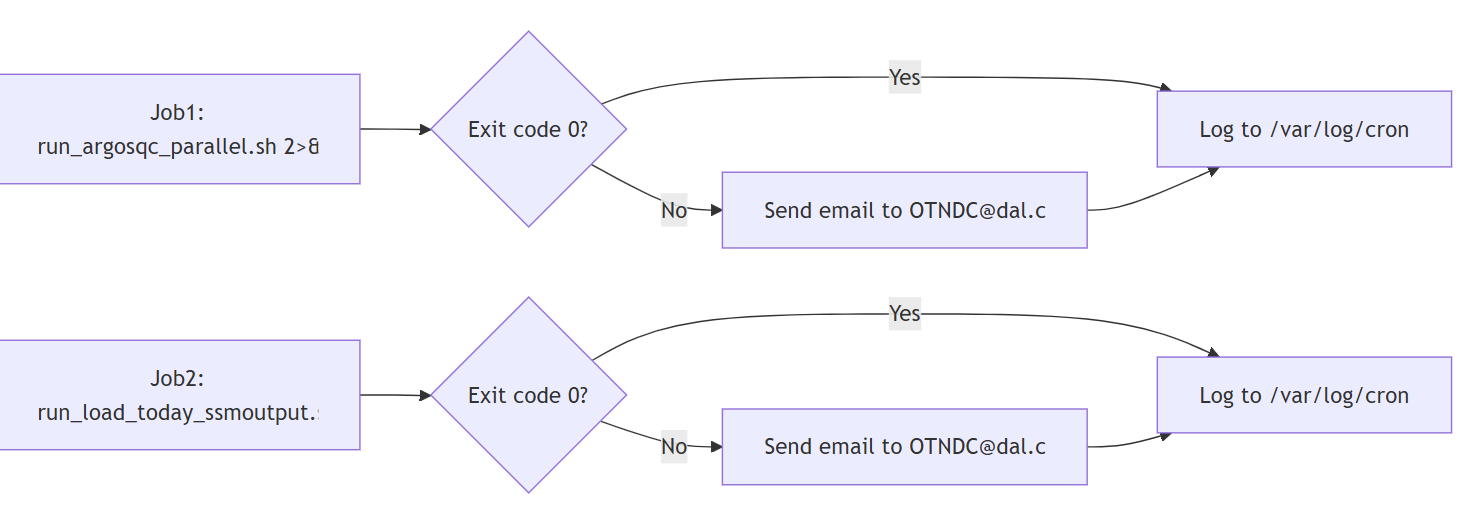

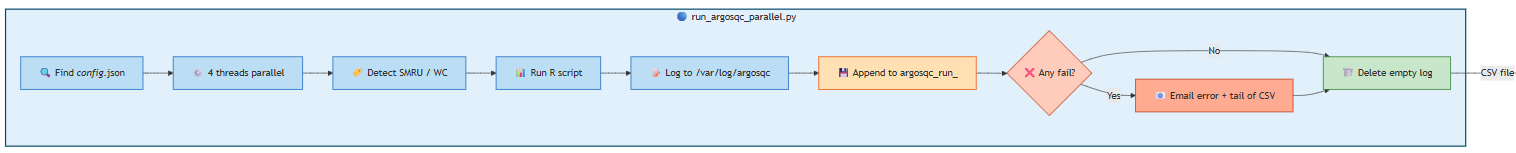

- 📋 ArgosQC process: default of 4 threads – downloads and runs ArgosQC for 4 configurations simultaneously.


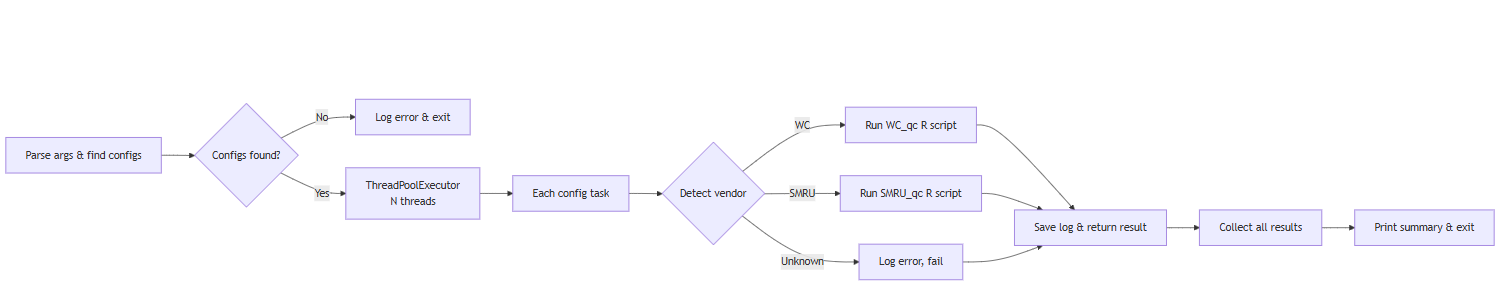


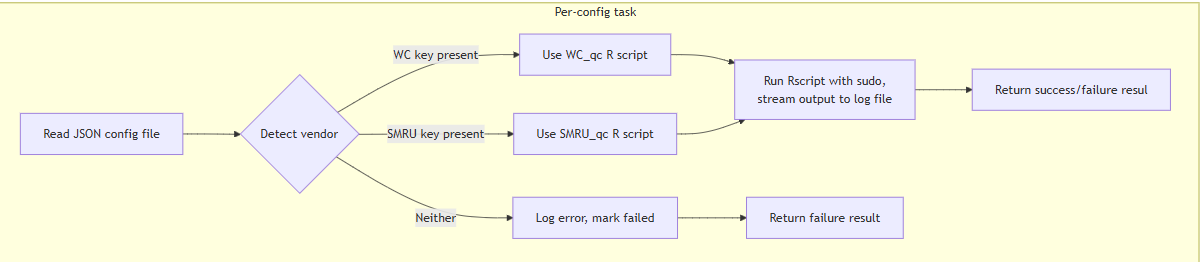

- Upload QCed (SSM output) to Near-Real-Time(NRT) DB process

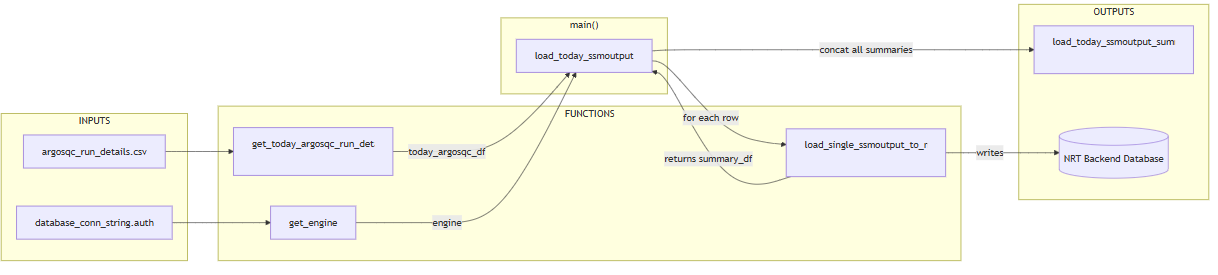


- NRT DB Schema


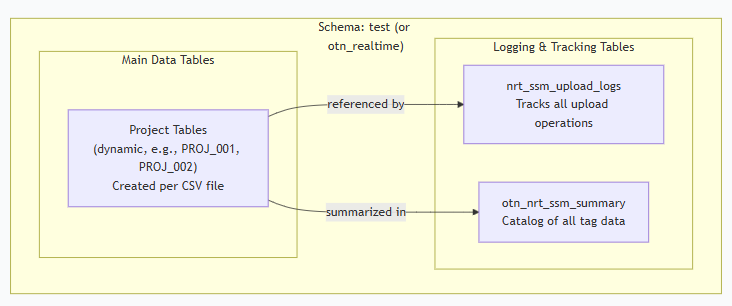




### 1. Checkout Github Repo: rt-sat-to-obis


- 📌 `sudo cd /opt/ont_nrt`
- 📌 `sudo git clone https://github.com/ocean-tracking-network/rt-sat-to-obis`

- 📌 `sudo git pull`

### 2. Install R 4.5.2 on System Level

- Install `R-core-4.5.2-1.el9.x86_64`
💡  ArgosQC is tested to work on this R version 

   📌
```
sudo dnf install epel-release
sudo dnf update
sudo dnf install R-core-4.5.2-1.el9.x86_64
```

- 📌 `sudo /bin/R`
```
R version 4.5.2 (2025-10-31) -- "[Not] Part in a Rumble"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-redhat-linux-gnu
...
```

- Check which package provides R executable: 📌 `dnf provides /bin/R`

```
Last metadata expiration check: 6 days, 15:33:57 ago on Thu 26 Mar 2026 09:04:23 PM.

R-core-4.5.2-1.el9.x86_64 : The minimal R components necessary for a functional runtime
Repo        : @System
Matched from:
Filename    : /usr/bin/R
```

### 3. Install ArgosQC  

- 📌 `sudo R`
- In R terminal/console: ArgosQC requires additional system‑level dependencies which need to be installed separately

  📌
```
remotes::install_github("ropensci/rnaturalearthhires")
remotes::install_github("ianjonsen/aniMotum", force = TRUE)
remotes::install_github("jmlondon/pathroutr", force = TRUE)
pinned_version <- "0.9.16"
remotes::install_github("ianjonsen/ArgosQC", ref = pinned_version, force = TRUE, dependency=NA)
```

### QC Project Configuration Hierarchy

- 📑 `input`

       -- <program1>
           -- <project1>
               -- config_<project1>.json
           -- <project2>
               -- config_<project2>.json
           
       -- <program3>
           -- <project3>
               -- config_<project3>.json

- 📑 Example project config hierarchy

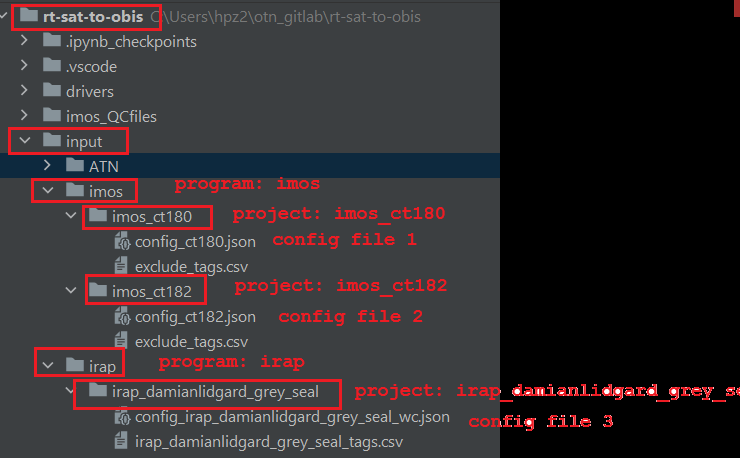

### 4. Manually Trigger the Pipeline

- 📌 `cd /opt/otn_nrt/rt-sat-to-obis`

- 📌 `sudo python py_nrt/run_argosqc_parallel.py`

```
[[28~2026-04-02 12:48:27,260 - MainThread - INFO - Searching for '*config*.json' in './input'
2026-04-02 12:48:27,262 - MainThread - INFO - Found 3 config files:
 ['./input/imos/imos_ct182/config_ct182.json', './input/imos/imos_ct180/config_ct180.json', './input/irap/irap_damianlidgard_grey_seal/config_irap_damianlidgard_grey_seal_wc.json']
2026-04-02 12:48:27,281 - ThreadPoolExecutor-0_1 - INFO - Starting: input/imos/imos_ct180/config_ct180.json with run_ArgosQC_smru_qc.R
2026-04-02 12:48:27,282 - ThreadPoolExecutor-0_0 - INFO - Starting: input/imos/imos_ct182/config_ct182.json with run_ArgosQC_smru_qc.R
2026-04-02 12:48:27,289 - ThreadPoolExecutor-0_2 - INFO - Starting: input/irap/irap_damianlidgard_grey_seal/config_irap_damianlidgard_grey_seal_wc.json with run_ArgosQC_wc_qc.R
2026-04-02 12:48:40,876 - ThreadPoolExecutor-0_0 - ERROR - Failed: input/imos/imos_ct182/config_ct182.json (exit code: 1)
2026-04-02 12:48:40,886 - ThreadPoolExecutor-0_1 - ERROR - Failed: input/imos/imos_ct180/config_ct180.json (exit code: 1)
^[[28~2026-04-02 12:50:40,390 - ThreadPoolExecutor-0_2 - INFO - Completed: input/irap/irap_damianlidgard_grey_seal/config_irap_damianlidgard_grey_seal_wc.json (exit code: 0)
2026-04-02 12:50:40,390 - MainThread - INFO - ============================================================
2026-04-02 12:50:40,391 - MainThread - INFO - SUMMARY
2026-04-02 12:50:40,391 - MainThread - INFO - ============================================================
2026-04-02 12:50:40,391 - MainThread - INFO - Total: 3
2026-04-02 12:50:40,391 - MainThread - INFO - Successful: 1
2026-04-02 12:50:40,391 - MainThread - INFO - Failed: 2
2026-04-02 12:50:40,391 - MainThread - INFO -
Failed configurations:
2026-04-02 12:50:40,391 - MainThread - INFO -   - input/imos/imos_ct182/config_ct182.json (vendor: SMRU, exit code: 1)
2026-04-02 12:50:40,391 - MainThread - INFO -     Log: /var/log/argosqc/config_ct182_20260402_124827.log
2026-04-02 12:50:40,391 - MainThread - INFO -   - input/imos/imos_ct180/config_ct180.json (vendor: SMRU, exit code: 1)
2026-04-02 12:50:40,391 - MainThread - INFO -     Log: /var/log/argosqc/config_ct180_20260402_124827.log
2026-04-02 12:50:40,391 - MainThread - INFO -

```


### 5. Logs, Results and Troubleshooting

- 📋 System log location: `/var/log/argosqc`

- 📌 `more /var/log/argosqc/config_ct180_20260402_132032.log`
```
Command: sudo Rscript /opt/otn_nrt/rt-sat-to-obis/r_nrt/run_ArgosQC_smru_qc.R input/imos/imos_ct180/config_ct180.json
Config file: input/imos/imos_ct180/config_ct180.json
R script: /opt/otn_nrt/rt-sat-to-obis/r_nrt/run_ArgosQC_smru_qc.R
============================================================

Loading required package: ArgosQC
Loading required package: jsonlite




[1] "2026-04-02 13:20:45 UTC"

[1] "input/imos/imos_ct180/config_ct180.json"
Error:
! 'qc/imos/imos_ct180/exclude_tags.csv' does not exist in current
  working directory: '/opt/otn_nrt/rt-sat-to-obis'.
Backtrace:
...
Execution halted
```

- 🔎 The issue was `qc/imos/imos_ct180/exclude_tags.csv` not found. This is a typo in the configuration file `input/imos/imos_ct180/config_ct180.json`
- Solution: in your local source code, ✏️ change `"output.dir": "qc/imos/imos_ct180",` ❌ to ` "output.dir": "input/imos/imos_ct180",` ✅. Commit the code change, push to the repo. Then run `sudo git pull` on JPhub to get the change. 

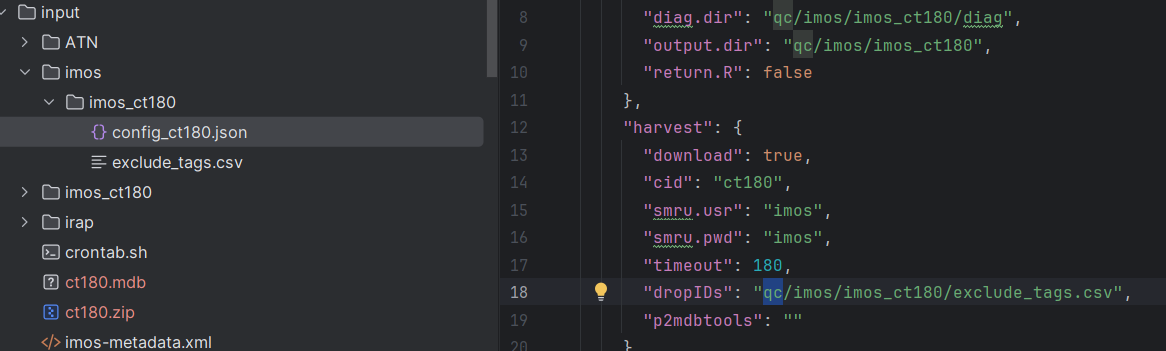

### 6. Review Result Details

- 📌 `more argosqc_run_details.csv`
```
program,output_dir,common_name,species,release_site,state_country,vendor,proj_id,qc_start_datetime
irap,qc/irap/irap_damianlidgard_grey_seal,grey seal,Halichoerus grypus,BRION ISLAND,Canada,WC,irap_damianlidgard_grey_seal,2026-04-02 13:20:32
program,output_dir,common_name,species,release_site,state_country,vendor,proj_id,qc_start_datetime
imos,qc/imos/imos_ct182,southern elephant seal,Mirounga leonina,Iles Kerguelen,French Overseas Territory,SMRU,imos_ct182,2026-04-02 13:20:32
imos,qc/imos/imos_ct180,southern elephant seal,Mirounga leonina,Kerguelen, French Southern and Antarctic Lands,SMRU,imos_ct180,2026-04-02 13:20:32
imos,qc/imos/imos_ct182,southern elephant seal,Mirounga leonina,Iles Kerguelen,French Overseas Territory,SMRU,imos_ct182,2026-04-02 13:31:19
imos,qc/imos/imos_ct180,southern elephant seal,Mirounga leonina,Kerguelen, French Southern and Antarctic Lands,SMRU,imos_ct180,2026-04-02 13:31:19
irap,qc/irap/irap_damianlidgard_grey_seal,grey seal,Halichoerus grypus,BRION ISLAND,Canada,WC,irap_damianlidgard_grey_seal,2026-04-02 13:31:19
```

### 7. Add to `cron` Nightly Job

- 📌 `sudo crontab -e` add 

```
MAILTO="OTNDC@dal.ca"
0 2 * * * /opt/otn_nrt/rt-sat-to-obis/run_argosqc_parallel.sh  2>&1
30 3 * * * /opt/otn_nrt/rt-sat-to-obis/run_load_today_ssmoutput.sh 2>&1
```

- Verify 📌 `sudo crontab -l` 📋 run at 2 AM and 3:30 AM everyday.
```
MAILTO="OTNDC@dal.ca"
0 2 * * * /opt/otn_nrt/rt-sat-to-obis/run_argosqc_parallel.sh  2>&1
30 3 * * * /opt/otn_nrt/rt-sat-to-obis/run_load_today_ssmoutput.sh 2>&1
```

- Check system cron log

  📌 `more /var/log/cron`
```
Apr  2 14:00:01 jphub.oceantrack.org CROND[1237106]: (root) CMD (cd /opt/otn_nrt/rt_sat_to_obis && /opt/conda/envs/rt-sat-to-obis/bin/python py_nrt
/run_argosqc_parallel.py >> /var/log/argosqc_cron.log 2>&1)
Apr  2 14:00:01 jphub.oceantrack.org CROND[1237093]: (root) CMDEND (cd /opt/otn_nrt/rt_sat_to_obis && /opt/conda/envs/rt-sat-to-obis/bin/python py_
nrt/run_argosqc_parallel.py >> /var/log/argosqc_cron.log 2>&1)
Apr  2 14:01:01 jphub.oceantrack.org CROND[1237117]: (root) CMD (run-parts /etc/cron.hourly)
```